## `merged_results.ipynb`

-----------------------

This notebook collates the results and plots them. Most methods are accessible in `inference.py`

In [1]:
import numpy as np 
import fitsio as fio
import pandas as pd 
import importlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from scipy.interpolate import interp1d
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable
from pathlib import Path
from scipy.integrate import simpson
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import curve_fit

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel

import src.statistics.inference as inference
import src.statistics.combination as comb
import src.statistics.cosmotools as ct
import src.statistics.corrfiles as cf
import src.statistics.calibration as cal

# Methods:
----------

We use the [Euclid](https://arxiv.org/pdf/2208.10503) approach (derived from Schmidt+2013):

We use : 
$n_{p, m}(z_{j, t})\propto \frac{\bar{\omega}_{\rm{sp},\:m}(r,\:z_{j, t})}{\sqrt{\bar{\omega}_{\rm{ss}}(r,\:z_{j, t})\bar{\omega}_{\rm{pp},\:m}(r)}}$ with $\bar{\omega}_{xy}(r, z_j)=\int_{r_{min}}^{r_{max}}W(r)\omega_{xy}(r, z_j)$ the scale averaged two point correlation function between samples x, y.

- $z_{j, t}$ : center of the fine bin j for the t tracer (ELG, LRG ...)
- $m$ : id of the tomographic bin
- $s$ : spectroscopic sample
- $p$ : photometric sample

Cosmology used (for distances in $h^{-1}Mpc$) :
- $\Omega_c = 0.258868$ (cold dark matter density fraction)
- $\Omega_b = 0.048252$ (baryon density fraction)
- $\Omega_m=\Omega_c+\Omega_b$ (matter density fraction)
- $h = 0.6777$
- $H_0 = h * 100$
- $\sigma_8 = 0.8$
- $n_s = 0.95$

DES Y3 Approach :

-----------------

$n_{p, m}(z_{j, t})\propto\frac{\bar{\omega}_{\rm{sp},\:m}(r,\:z_{j, t})}{\sqrt{\bar{\omega}_{\rm{ss}}(r,\:z_{j, t})\bar{\omega}_{\rm{pp},\:m}(r, z_{j, t})\sigma_j}}$ with $\bar{\omega}_{xy}(r, z_j)=\int_{r_{min}}^{r_{max}}W(r)\omega_{xy}(r, z_j)$

This approach does not really work well due to the very high variations in $\sigma_j$ caused by the photometric method itself (redshift spikes)


In [2]:
ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/')
bins_hsc = np.arange(0.3, 1.8, 0.3)
markers = ['x', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']
colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
colors = [cmap(0.8) for cmap in colormaps]
tracers = ['BGS_ANY', 'LRG', 'ELGnotqso', 'QSO']
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELGnotqso' : 'ELG',
    'QSO' : 'QSO',
}
sigmaj_corr = 1 # temporary

### Passive evolution fitting power law

Combining results

In [28]:
path_dictionary = {
    'HSC' : ROOT / 'v1' / f'autos_NGC', # with no wpp correction, is unused
    'DESI_NGC' : ROOT / 'v7' / f'autos_NGC',
    'DESI_SGC' : ROOT / 'v7' / f'autos_SGC',
    'DESIxHSC' : ROOT / 'v1' / f'cross',
}

In [25]:
outdir = ROOT / 'merged_v1_v10'

In [24]:
importlib.reload(inference)
importlib.reload(comb)
importlib.reload(ct)
importlib.reload(cf)
inference.merge_estimators(path_dictionary=path_dictionary, outdir=outdir, verbose=True)

AssertionError: Path /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/v7/cross does not exist

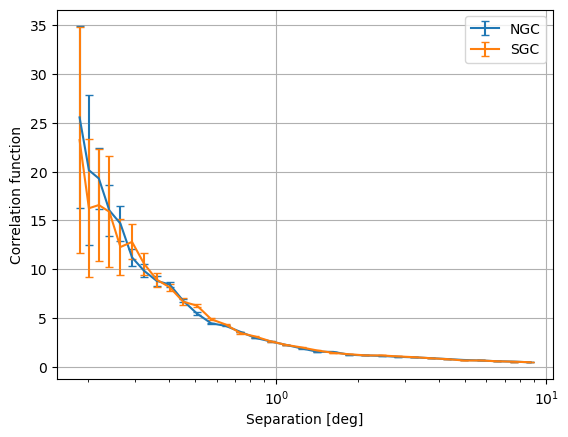

In [17]:
from pycorr import TwoPointEstimator
tgt = 'LRG'  # Target tracer
b = 10
tpcf1 = TwoPointEstimator.load(f'/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/v10/autos_NGC/{tgt}x{tgt}/{tgt}x{tgt}_b1x{b}_b2x{b}_moc1.npy')
tpcf2 = TwoPointEstimator.load(f'/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/v10/autos_SGC/{tgt}x{tgt}/{tgt}x{tgt}_b1x{b}_b2x{b}_moc3.npy')
plt.errorbar(ct.arcsec2hMpc(0.5*(tpcf1.edges[0][1:] + tpcf1.edges[0][:1])*3600, z=2), tpcf1.corr, np.sqrt(np.diag(tpcf1.cov())**2), label='NGC', capsize=3)
plt.errorbar(ct.arcsec2hMpc(0.5*(tpcf2.edges[0][1:] + tpcf2.edges[0][:1])*3600, z=2), tpcf2.corr, np.sqrt(np.diag(tpcf2.cov())**2), label='SGC', capsize=3)
plt.xscale('log')
plt.xlabel('Separation [deg]')
plt.ylabel('Correlation function')
plt.legend()
plt.grid()

In [30]:
path_dictionary.update({
    'MergedxMerged' : outdir,
    'MergedxHSC' : outdir,
})

In [69]:
importlib.reload(inference)
importlib.reload(comb)
importlib.reload(ct)
importlib.reload(cf)
meas = inference.full_npz_tomo(
    path_dictionary=path_dictionary,
    scale_cuts=[.2, 3],
    tracer='Merged',
    tomo_bin=1,
    verbose=True,
)
# let's remove NaN values from last bin
print(meas)

Using merged method for tracer Merged and tomo bin 1.
(array([-2.43139983e-02,  1.59899557e-01,  7.28904874e-01,  6.77130322e-01,
        1.25781903e+00,  2.13230103e+00,  3.28387507e+00,  3.57880298e+00,
        4.22744374e+00,  4.35755865e+00,  4.17638930e+00,  2.59456310e+00,
        9.55035487e-01,  1.65031100e-01,  2.30352641e-02,  4.55472170e-02,
       -1.70496963e-01,  1.27163980e-01, -2.93829997e-02,  4.23678343e-02,
        2.28018936e-01,  1.15771706e-01, -1.88988534e-01,  3.57730861e-03,
        1.94550963e-01,  2.42564028e-01, -1.80469661e-01, -1.43234128e-01,
        2.11133950e-01,  3.56372620e-01,  1.45025776e-01,  3.56414714e-02,
        5.10734980e-02, -7.88593031e-02, -2.62291936e-01, -1.61385758e-01,
       -1.43734894e-01,  1.22357021e-03, -2.57734246e-01, -3.83256344e-01,
       -2.51830940e-03,  1.51732496e-01, -2.63713994e-01, -9.43431785e-02,
       -3.41834160e-01, -1.75564900e-01, -1.87561307e-01,  1.41528633e-01]), array([0.2979341 , 0.26074525, 0.28555563, 

Integrated p(z) = 1.365
Expected p(z) = 0.345


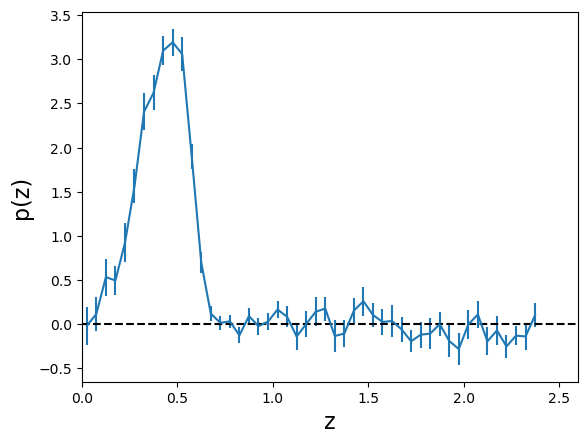

In [70]:
zbins = np.arange(0.0, 2.4 + 0.05, 0.05)
zval = zbins[:-1] + np.diff(zbins) / 2
plt.errorbar(zval, meas[0]/simpson(meas[0], zval), meas[1]/simpson(meas[0], zval))
plt.axhline(0, color='k', linestyle='--')
plt.xlabel('z', fontsize=16)
plt.ylabel('p(z)', fontsize=16)
plt.xlim(0, 2.6)
print(f'Integrated p(z) = {simpson(meas[0], zval):.3f}')
print(f'Expected p(z) = {simpson(np.multiply(zval, meas[0]/simpson(meas[0], zval)), zval):.3f}')

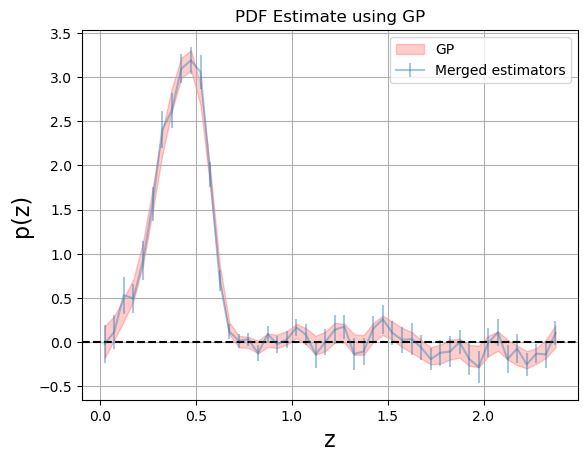

In [71]:
dz = np.diff(zval)[0]
y = meas[0] / np.sum(meas[0] * np.diff(zbins))
y_err = meas[1] / np.sum(meas[0] * np.diff(zbins))

X = zval.reshape(-1, 1)
kernel = kernel = ConstantKernel(1.0) * Matern(nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=(y_err**2), n_restarts_optimizer=10)

assert np.all(np.isfinite(X))
assert np.all(np.isfinite(y))
assert np.all(np.isfinite(y_err))
assert X.shape == (len(y), 1)

gp.fit(X, y)

y_mean, y_std = gp.predict(X, return_std=True)

y_pdf = y_mean / np.trapz(y_mean, zval)
y_stderr = y_std / np.trapz(y_mean, zval)

# Plot
plt.errorbar(zval, y, y_err, label='Merged estimators', alpha=0.4)
plt.fill_between(zval, y_pdf - y_stderr, y_pdf + y_stderr, alpha=0.2, label='GP', color='red')
plt.axhline(0, color='k', linestyle='--')
plt.grid(True)
plt.xlabel('z', fontsize=16)
plt.ylabel('p(z)', fontsize=16)
plt.legend()
plt.title('PDF Estimate using GP')
plt.show()

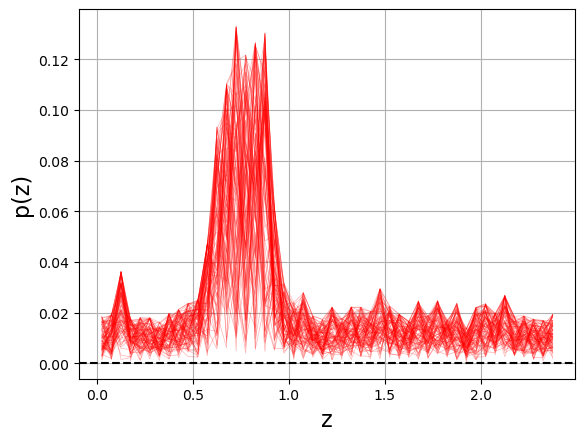

In [55]:
import calibration as cal
importlib.reload(cal)
for i in range(100):
    shuffle = np.random.permutation(len(meas[0]))
    # compute pz with shuffled data
    pz = cal.compute_pz(meas[0][shuffle], meas[1][shuffle])
    # undo shuffle
    pz = np.array(pz)[np.argsort(shuffle)]
    plt.plot(zval, pz, color='red', alpha=0.3, lw=0.5)
plt.axhline(0, color='k', linestyle='--')
plt.xlabel('z', fontsize=16)
plt.ylabel('p(z)', fontsize=16)
plt.grid()

Using merged method for tracer Merged and tomo bin 1.
Using merged method for tracer Merged and tomo bin 2.
Using merged method for tracer Merged and tomo bin 3.
Using merged method for tracer Merged and tomo bin 4.
Tomo 1 :
0.4717812524298891
0.47099337552846443

Tomo 2 :
0.762527685801856
0.8986337790997184

Tomo 3 :
1.0621850190335709
1.6537570722761121

Tomo 4 :
1.3013253001934832
1.9775847983070052



(-1.2, 4.5)

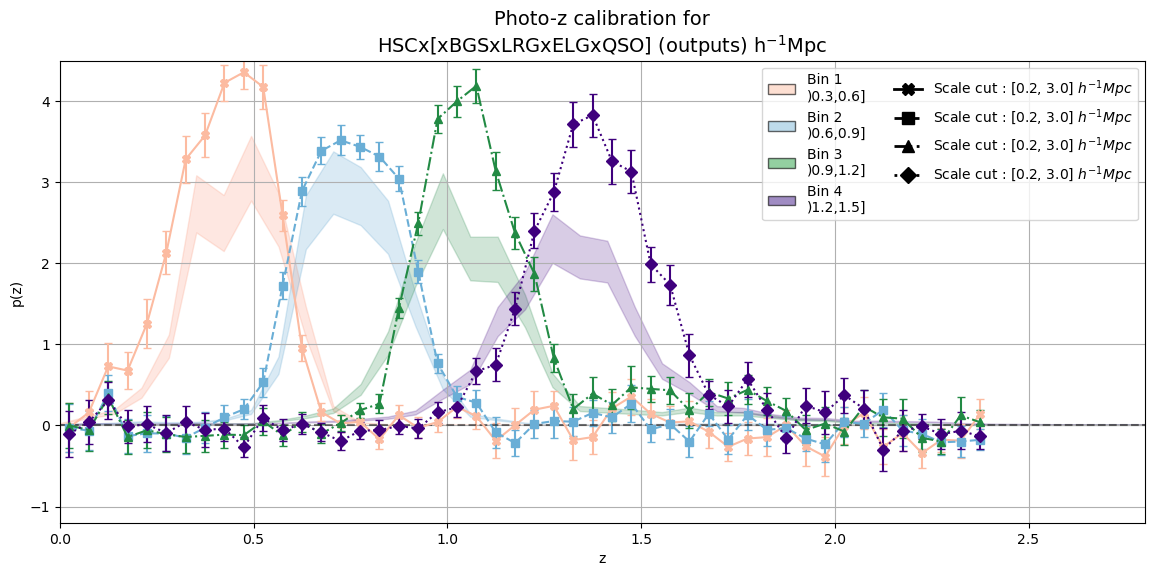

In [ ]:
importlib.reload(inference)
ncurves = 0
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELGnotqso' : 'ELG',
    'QSO' : 'QSO',
}

bins_hsc = np.arange(0.3, 1.8, 0.3)

colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
markers = ['X', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']
tomo_bin_dnnz = np.loadtxt('hsc_pz/data/tomographic_binning_dnnz.dat')

fig, ax = plt.subplots(figsize=(14, 6))

scale_cut = [.2, 3]

tomo_interest = [1, 2, 3, 4]  # tomographic bins of interest
title = 'Photo-z calibration for\nHSCx['
zbins = np.arange(0.0, 2.4 + 0.05, 0.05)

nz = []
nz_err = []
for tomo in tomo_interest:
    zval = zbins[:-1] + np.diff(zbins) / 2
    tomo_nz, tomo_nz_err = inference.full_npz_tomo(
        path_dictionary=path_dictionary,
        scale_cuts=scale_cut,
        tracer="Merged",
        tomo_bin=tomo,
        rebin=1,
        )
    nonnanz = ~np.isnan(tomo_nz)
    tomo_nz = tomo_nz[nonnanz]
    tomo_nz_err = tomo_nz_err[nonnanz]
    zval = zval[nonnanz]
    nz_int = simpson(tomo_nz, x=zval)
    nz.append(tomo_nz/nz_int)
    nz_err.append(tomo_nz_err/nz_int)

    ax.errorbar(
        x=zval, 
        y=nz[tomo-1],
        yerr=nz_err[tomo-1],#/normalization, 
        capsize=3,
        marker=markers[tomo-1], 
        linestyle=linestyles[tomo-1],
        markersize=6,   
        alpha=1,
        color=colormaps[tomo-1]((tomo)/4),
        )
        
    title+= f'x{tracer_trad[tracers[tomo-1]]}'

mids = tomo_bin_dnnz[:, 0]
mask_mids = mids < 2.725

dnnz_list = []
mu_list = []
cov_list = []

ids_to_skip = []

for dnnz_idx in range(0, 4):
    ncurves += 1

    dnnz, mu, cov = comb.hsc_dnnz_error(tomo_bin_dnnz[:, dnnz_idx+1], mids)
    dnnz_list.append(np.percentile(dnnz, 50, axis=0))
    mu_list.append(mu)
    cov_list.append(cov)

    ax.fill_between(
        mids, 
        np.percentile(dnnz, 16, axis=0), 
        np.percentile(dnnz, 84, axis=0), 
        color=colormaps[dnnz_idx]((dnnz_idx+2)/5), 
        alpha=0.2
        )
        
title+=f'] ({ROOT.name}) ' +r'$\rm{h}^{-1}\rm{Mpc}$'
ax.set_xlabel('z')
ax.set_ylabel('p(z)')

legend_elements = []

for bin_id in tomo_interest:
    patch = Patch(
        facecolor=colormaps[bin_id-1](bin_id/len(bins_hsc)),
        alpha=0.6,
        edgecolor='black',
        label=f'Bin {bin_id}\n){bins_hsc[bin_id-1]:.1f},{bins_hsc[bin_id]:.1f}]',
    )
    legend_elements.append(patch)

for i, (marker, linestyle, tracer) in enumerate(zip(markers, linestyles, tracers)):
    element = Line2D(
        [0], 
        [0], 
        color='black', 
        marker=marker, 
        linestyle=linestyle, 
        markersize=8, 
        label=f'Scale cut : [{scale_cut[0]:.1f}, {scale_cut[1]:.1f}] ' + r'$h^{-1}Mpc$', 
        linewidth=2
    )
    legend_elements.append(element)

ax.legend(
    handles=legend_elements, 
    loc='upper right', 
    ncol=2, 
    fontsize=10,
)

for i in range(len(nz)):
    print(f'Tomo {i+1} :')
    assert len(nz[i]) == len(zval), f'Length mismatch for tomo {i+1}'
    print(f'{simpson(np.multiply(mids, dnnz_list[i]), x=mids)}')
    print(f'{simpson(np.multiply(nz[i], zval), x=zval)}\n')

ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.grid()
ax.set_title(title, fontsize=14)
ax.set_xlim(0, 2.8)
ax.set_ylim(-1.2, 4.5)

## Gaussian Mixture Models

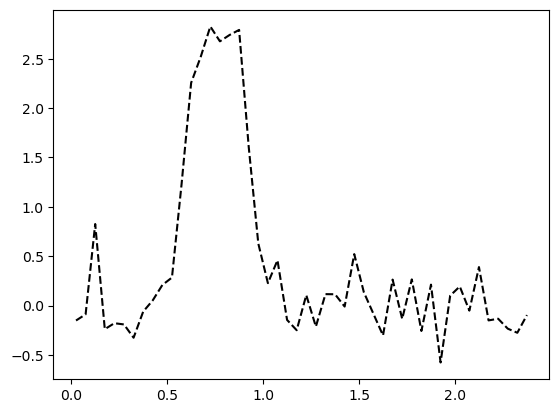

In [68]:
plt.plot(zval, meas[0]/simpson(meas[0], zval), color='black', linestyle='--', label='Merged estimators')